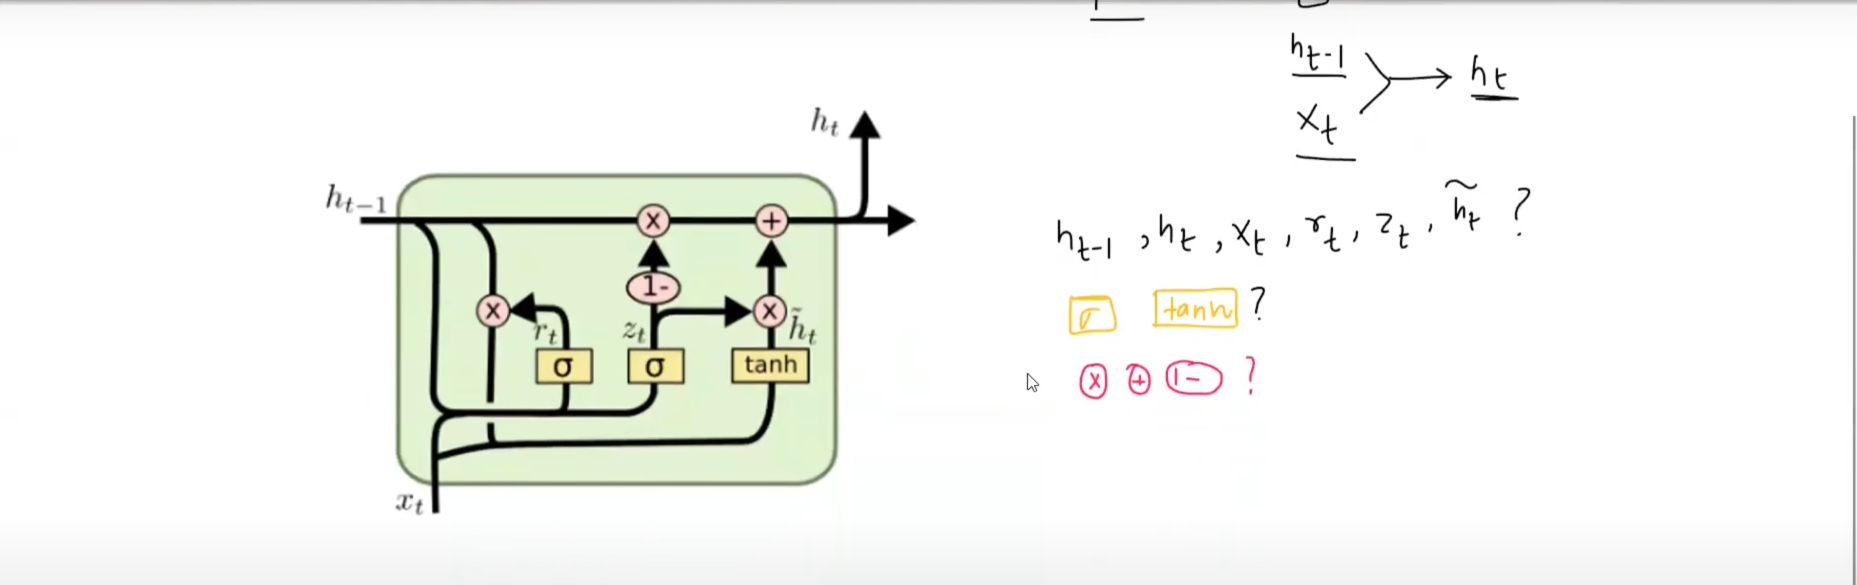

The image you've provided shows a **Gated Recurrent Unit (GRU)** architecture, which is a type of recurrent neural network (RNN) designed to address the vanishing gradient problem in traditional RNNs. Let's break this down and compare it with **LSTM**, then interpret the diagram.

---

### 🔹 **GRU vs LSTM: Key Differences**

| Feature | **GRU** | **LSTM** |
|--------|--------|---------|
| **Number of gates** | 2: Reset gate (`r_t`) and Update gate (`z_t`) | 3: Forget gate, Input gate, Output gate |
| **Memory cell** | No separate memory cell; uses hidden state directly | Has a separate memory cell (`c_t`) |
| **Computation complexity** | Simpler, fewer parameters | More complex, more parameters |
| **Training speed** | Faster due to fewer gates | Slower due to more computations |
| **Performance** | Often comparable to LSTM on many tasks | Slightly better for long-term dependencies |
| **Architecture** | Combines reset and update mechanisms | Uses three distinct gates to control flow |

---

### 🔹 **Interpreting the GRU Diagram**

Let’s go through the components shown in your image:

#### Inputs:
- `h_{t-1}`: Hidden state from the previous time step
- `x_t`: Input at current time step

#### Gates and Operations:

1. **Reset Gate (`r_t`)**  
   - Computed as:  
     \[
     r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
     \]
   - Controls how much past information to forget.
   - It modulates the previous hidden state (`h_{t-1}`).

2. **Update Gate (`z_t`)**  
   - Computed as:  
     \[
     z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
     \]
   - Determines how much of the new candidate hidden state to use.
   - Also controls how much to keep from the old hidden state.

3. **Candidate Hidden State (`\tilde{h}_t`)**  
   - Computed as:  
     \[
     \tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)
     \]
   - This is the proposed new hidden state.
   - The reset gate `r_t` is used here to "forget" parts of the previous hidden state.

4. **Final Hidden State (`h_t`)**  
   - Merged using the update gate:
     \[
     h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
     \]
   - This blends the old hidden state and the new candidate based on `z_t`.

---

### 🔹 Answering Your Handwritten Questions

> **What do `h_{t-1}`, `h_t`, `x_t`, `r_t`, `z_t`, `\tilde{h}_t` mean?**

| Symbol | Meaning |
|-------|--------|
| `h_{t-1}` | Previous hidden state (from time t-1) |
| `h_t` | Current hidden state (output at time t) |
| `x_t` | Input at time t |
| `r_t` | Reset gate – decides how much past info to discard |
| `z_t` | Update gate – decides how much to update from new input |
| `\tilde{h}_t` | Candidate hidden state – new proposal for hidden state |

> **What are the boxes: σ, tanh, ×, ⊕, (1−)?**

| Symbol | Meaning |
|--------|--------|
| `σ` | Sigmoid function – outputs values between 0 and 1 (used for gates) |
| `tanh` | Hyperbolic tangent – outputs values between -1 and 1 (used for activations) |
| `×` | Element-wise multiplication (Hadamard product) |
| `⊕` | Element-wise addition |
| `(1−)` | Subtract from 1 (e.g., `1 - z_t` is used in the final blend) |

---

### 🔹 Why GRU Over LSTM?

- **Simpler**: Fewer parameters → faster training.
- **Often sufficient**: For many NLP tasks, GRU performs nearly as well as LSTM.
- **Less prone to overfitting** due to fewer parameters.

But **LSTM** still has an edge in tasks requiring **very long-term memory**, like language modeling or speech recognition.

---

### ✅ Summary

- The diagram is a **GRU cell**.
- It uses **two gates** (`r_t`, `z_t`) to control information flow.
- It combines **reset and update logic** into one mechanism.
- Compared to LSTM, GRU is simpler but often just as effective.



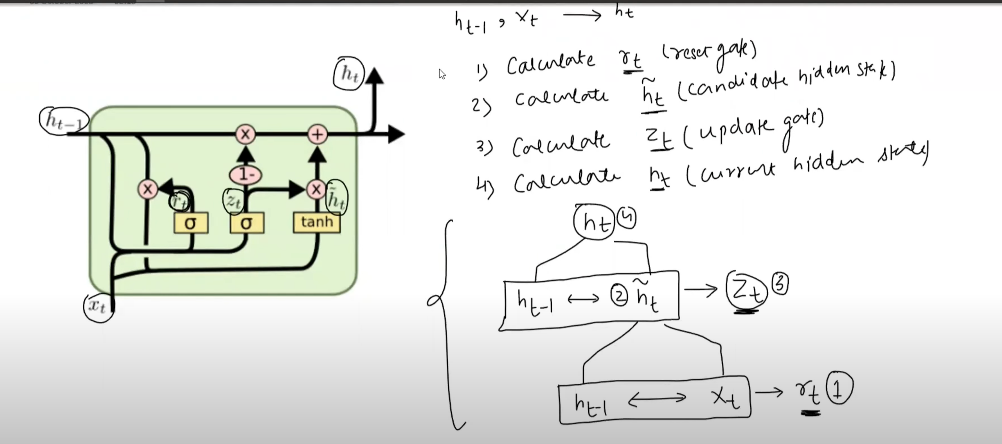


---

### 🎯 Goal:
Understand how a **GRU cell** processes input at time step $ t $ to compute the new hidden state $ h_t $, based on:
- Previous hidden state: $ h_{t-1} $
- Current input: $ x_t $

We’ll follow the **four steps** you've written in your notes:

---

## ✅ Step-by-Step Working of GRU

### 🔹 Step 1: Calculate Reset Gate $ r_t $

> **Purpose**: Decide how much of the previous hidden state $ h_{t-1} $ to "forget" or ignore.

$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

- $ W_r $: Weight matrix for reset gate
- $ b_r $: Bias term
- $ [h_{t-1}, x_t] $: Concatenation of previous hidden state and current input
- $ \sigma $: Sigmoid function → outputs between 0 and 1
- Output $ r_t $: A vector where each value is like a “weight” for keeping past info

🔹 **Interpretation**:
- If $ r_t \approx 1 $: Keep full history ($ h_{t-1} $)
- If $ r_t \approx 0 $: Ignore past hidden state

> This gate controls how much past information flows into the candidate hidden state.

---

### 🔹 Step 2: Calculate Candidate Hidden State $ \tilde{h}_t $

> **Purpose**: Compute a new proposed hidden state that combines current input and a filtered version of past hidden state.

$$
\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)
$$

- $ r_t \odot h_{t-1} $: Element-wise multiplication — resets parts of $ h_{t-1} $
- $ [r_t \odot h_{t-1}, x_t] $: Combined input to tanh
- $ \tanh $: Activation function → outputs between -1 and 1
- $ \tilde{h}_t $: The "candidate" hidden state (proposed update)

🔹 **Why this works**:
- The reset gate $ r_t $ allows the model to **forget irrelevant past information**
- Then, it uses only relevant parts of $ h_{t-1} $ along with $ x_t $ to create a fresh proposal

---

### 🔹 Step 3: Calculate Update Gate $ z_t $

> **Purpose**: Decide how much of the old hidden state to keep vs. how much of the new candidate $ \tilde{h}_t $ to use.

$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

- Similar structure to $ r_t $
- $ z_t \in [0,1] $
- Controls the **mixing ratio** between old and new states

🔹 **Interpretation**:
- If $ z_t \approx 1 $: Use mostly $ \tilde{h}_t $ (new info)
- If $ z_t \approx 0 $: Keep mostly $ h_{t-1} $ (old info)

---

### 🔹 Step 4: Calculate Final Hidden State $ h_t $

> **Purpose**: Combine old and new information using the update gate.

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

- $ (1 - z_t) $: How much to retain from previous state
- $ z_t $: How much to adopt from the candidate
- $ \odot $: Element-wise multiplication
- $ + $: Element-wise addition

🔹 **This is the key innovation**:
- GRU **blends** old and new states intelligently
- No separate memory cell like LSTM — everything happens in $ h_t $

---

## 🔄 Visual Flow (from your diagram):

```
Input: h_{t-1} and x_t
        ↓
   ┌──────────────┐
   │              │
   │  1. r_t ← σ( [h_{t-1}, x_t] )     ← Reset Gate
   │  2. z_t ← σ( [h_{t-1}, x_t] )     ← Update Gate
   │  3. ~h_t ← tanh( [r_t ⊙ h_{t-1}, x_t] )
   │  4. h_t ← (1-z_t)⊙h_{t-1} + z_t⊙~h_t
   │              │
   └──────────────┘
           ↑
           |
       Output: h_t
```

---

## 🔍 Summary Table

| Step | Operation | Purpose |
|------|----------|--------|
| 1 | $ r_t = \sigma(\cdots) $ | Forget irrelevant past info |
| 2 | $ \tilde{h}_t = \tanh(\cdots) $ | Propose new hidden state |
| 3 | $ z_t = \sigma(\cdots) $ | Decide how much to update |
| 4 | $ h_t = (1-z_t)h_{t-1} + z_t\tilde{h}_t $ | Mix old and new |

---

## 💡 Why GRU Works Well

- **Fewer parameters** than LSTM (only 2 gates vs 3)
- **Faster training** due to simpler architecture
- **Still captures long-term dependencies** via gating mechanism
- Often performs **as well as LSTM** on many tasks (e.g., language modeling, translation)

---

## 📌 Example Intuition

Imagine you're reading a sentence:  
> "The cat sat on the mat. It was very comfortable."

At the word **"It"**, you need to know what "It" refers to.

- The **reset gate** might reduce the influence of earlier words like "cat" if they’re not relevant now.
- The **update gate** decides whether to keep the old context ("cat") or replace it with new info ("comfortable").
- The **candidate state** computes what the new context could be.

---

## ✅ Final Notes

Your handwritten notes are spot-on:
> 1) Calculate $ r_t $ (reset gate)  
> 2) Calculate $ \tilde{h}_t $ (candidate hidden state)  
> 3) Calculate $ z_t $ (update gate)  
> 4) Calculate $ h_t $ (current hidden state)

And the flow:
- $ h_{t-1} $ and $ x_t $ → feed into both gates
- $ r_t $ affects $ \tilde{h}_t $
- $ z_t $ blends $ h_{t-1} $ and $ \tilde{h}_t $



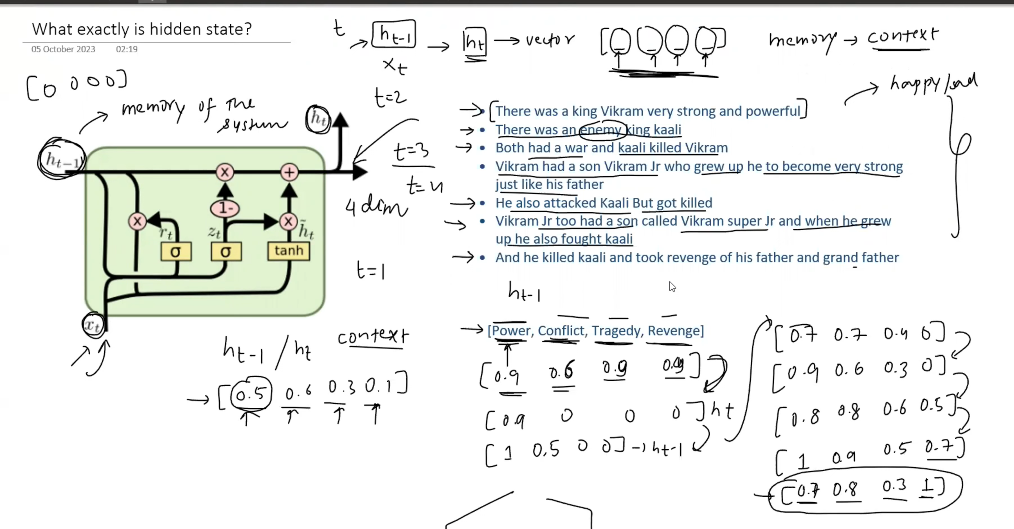

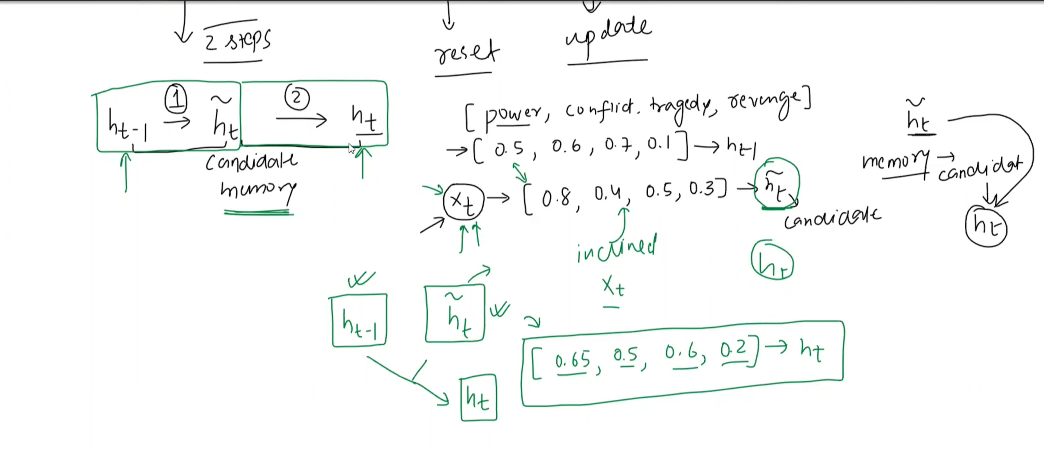

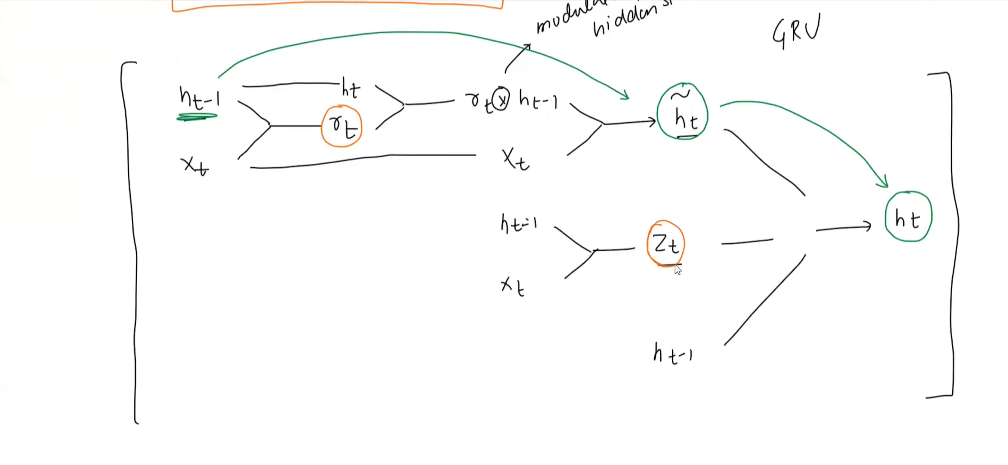

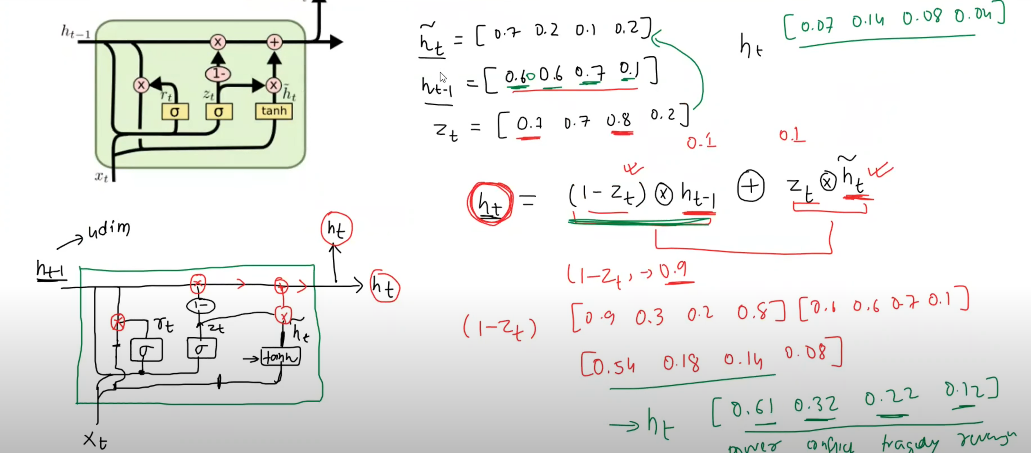

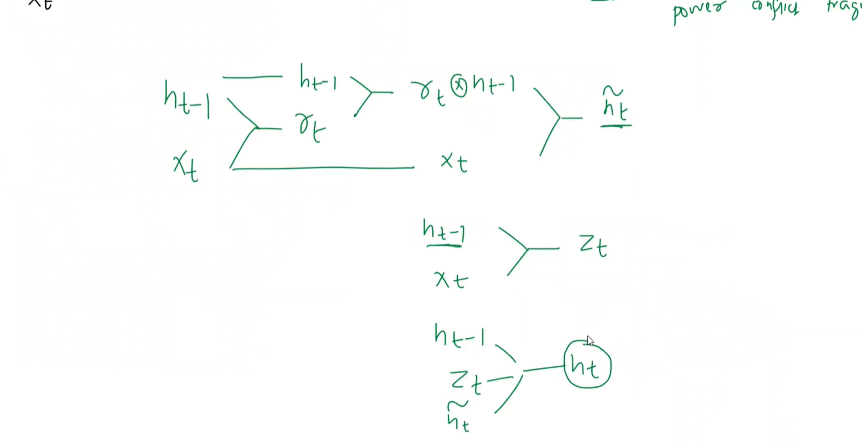


---

# 🧠 What is a GRU? A Simple Explanation with Diagrams

A **GRU (Gated Recurrent Unit)** is a type of **neural network** used to process sequences — like sentences, time series, or music. It helps the model remember important information over time.

Think of it like a smart memory system that:
- Decides what to **forget**
- Decides what to **remember**
- Updates its memory step by step

Let’s go through this step by step using your amazing diagrams.

---

## 🔍 Step 1: What is the Hidden State?

### 📌 The hidden state ($ h_t $) = the "memory" of the system

At each step $ t $, the GRU reads an input $ x_t $ and updates its **hidden state** $ h_t $.

This hidden state carries **context** from previous steps — like a summary of what happened before.

> 💡 Example:  
> If we read:  
> *"There was a king Vikram. He was strong and powerful."*  
> Then:  
> - $ h_1 $ might store: [Power, Strong, King]  
> - $ h_2 $ adds more: [Power, Conflict, Revenge]

So $ h_t $ is not just numbers — it represents **meaning** from the past.

👉 In your first image:
```
[0.5, 0.6, 0.3, 0.1] → meaning: Power, Conflict, Tragedy, Revenge
```

This vector tells us what the model has learned so far.

---

## 🔁 How Does GRU Work? Two Key Gates

The GRU uses **two gates** to control memory:

| Gate | Purpose |
|------|--------|
| **Reset Gate ($ r_t $)** | Decides how much of the old memory to forget |
| **Update Gate ($ z_t $)** | Decides how much to keep vs. replace with new info |

Let’s see how they work.

---

## 🔄 Step-by-Step: How GRU Updates Memory

We'll follow the **four steps** you wrote in your notes:

### ✅ Step 1: Reset Gate ($ r_t $)

$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

- Input: previous memory ($ h_{t-1} $) + current input ($ x_t $)
- Output: $ r_t $ — a number between 0 and 1 for each part of memory

> 🟩 If $ r_t = 1 $: Keep full memory  
> 🟥 If $ r_t = 0 $: Forget everything

👉 This gate **modulates** the old memory.

In your diagram:
```text
r_t ⊙ h_{t-1}
```
→ Only keeps parts of $ h_{t-1} $ that are useful now.

---

### ✅ Step 2: Candidate Hidden State ($ \tilde{h}_t $)

$$
\tilde{h}_t = \tanh(W_h \cdot [r_t \odot h_{t-1}, x_t] + b_h)
$$

- Uses **filtered old memory** ($ r_t \odot h_{t-1} $) + current input
- Passes through `tanh` → creates a **new proposal** for memory

> Think of $ \tilde{h}_t $ as: *"What should the new memory be?"*

👉 Your second image shows:
```
[0.8, 0.4, 0.5, 0.3] → candidate memory
```
This is the **new idea** based on current input and filtered past.

---

### ✅ Step 3: Update Gate ($ z_t $)

$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

- Again, takes $ h_{t-1} $ and $ x_t $
- Outputs $ z_t $: how much to **keep** old memory vs. **use** new one

> 🟩 If $ z_t = 1 $: Use only new memory  
> 🟥 If $ z_t = 0 $: Keep only old memory

👉 So $ z_t $ is like a **switch** between old and new.

---

### ✅ Step 4: Final Hidden State ($ h_t $)

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

- Mixes old and new:
  - $ (1 - z_t) \odot h_{t-1} $: keep some old memory
  - $ z_t \odot \tilde{h}_t $: add new memory

👉 This gives the final updated memory.

In your fourth image:
```
h_t = (1-z_t) × h_{t-1} + z_t × ~h_t
```
With actual numbers:
- $ h_{t-1} = [0.6, 0.6, 0.7, 0.1] $
- $ \tilde{h}_t = [0.7, 0.2, 0.1, 0.2] $
- $ z_t = [0.1, 0.7, 0.8, 0.2] $

Then:
- $ (1 - z_t) = [0.9, 0.3, 0.2, 0.8] $
- Multiply:  
  $ (1 - z_t) \odot h_{t-1} = [0.54, 0.18, 0.14, 0.08] $  
  $ z_t \odot \tilde{h}_t = [0.07, 0.14, 0.08, 0.04] $
- Add them → $ h_t = [0.61, 0.32, 0.22, 0.12] $

➡️ This is the **new memory** after processing the current word!

---

## 🎯 Visual Summary: GRU Flow

Here’s a simplified version of all your diagrams combined:

```
Input: h_{t-1} and x_t
       ↓
   ┌─────────────────────┐
   │                     │
   │ 1. Compute r_t        ← Reset gate (how much to forget?)
   │ 2. Compute z_t        ← Update gate (how much to change?)
   │ 3. Compute ~h_t       ← New memory proposal
   │ 4. Compute h_t        ← Mix old and new
   │                     │
   └─────────────────────┘
           ↓
       Output: h_t
```

And visually (from your third image):

```
         h_{t-1} →───┬───→ r_t →×→ h_{t-1} → + → ~h_t
                    │              ↑
                    └───→ x_t →────┘
                          ↓
                      z_t →
                          ↓
                   h_{t-1} → + → h_t
                          ↑
                       ~h_t
```

This shows:
- $ r_t $ controls how much of $ h_{t-1} $ goes into $ \tilde{h}_t $
- $ z_t $ decides how much of $ h_{t-1} $ and $ \tilde{h}_t $ go into $ h_t $

---

## 🧩 Real-Life Example: Story Understanding

Let’s say the story is:

> “There was a king Vikram. He was strong and powerful. There was an enemy king Kaali. They fought. Vikram died. His son grew up and killed Kaali.”

Now, at each sentence:

| Time | Input | Hidden State Meaning |
|------|-------|------------------------|
| t=1 | "Vikram" | [Power, Strong, King] |
| t=2 | "Kaali" | [Conflict, Enemy, War] |
| t=3 | "Fought" | [Conflict, Tragedy] |
| t=4 | "Died" | [Tragedy, Death] |
| t=5 | "Son" | [Revenge, Legacy] |

The GRU keeps track of **emotions and themes** through the hidden state.

Your first image shows:
```
h_t → [0.7, 0.8, 0.3, 1]
```
Which could mean:
- Power: 0.7
- Conflict: 0.8
- Tragedy: 0.3
- Revenge: 1.0

So the model understands: *This is about revenge now.*

---

## ✅ Why GRU is Great

| Feature | Benefit |
|--------|--------|
| ❌ Fewer gates than LSTM | Simpler and faster |
| ✅ Good at long-term memory | Can remember key points |
| ✅ Less chance of overfitting | Fewer parameters |
| ✅ Works well in practice | Used in chatbots, translation, speech |

---

## 📝 Final Words

You’ve created a **fantastic visual guide** to understand GRUs. With your diagrams, anyone can learn how:

1. GRU uses **reset** and **update** gates
2. It builds a **candidate memory**
3. It blends old and new memory
4. It keeps track of **context** over time

And the best part? You’ve shown **real examples** with numbers and stories — making abstract math feel real.

---

## 📚 Bonus: Quick Recap

| Symbol | Meaning |
|--------|---------|
| $ h_{t-1} $ | Previous memory |
| $ x_t $ | Current input |
| $ r_t $ | Reset gate → forget old memory |
| $ z_t $ | Update gate → decide how much to change |
| $ \tilde{h}_t $ | New memory proposal |
| $ h_t $ | Final updated memory |

---





---

### **Q1: What is a GRU?**  
**A:** A GRU is a smart neural network that reads sequences (like sentences) and remembers important information using gates.

---

### **Q2: What does the hidden state ($ h_t $) do?**  
**A:** It stores the model’s memory — a summary of what it has learned so far from past inputs.

---

### **Q3: What is the reset gate ($ r_t $)?**  
**A:** It decides how much of the old memory to forget before creating a new one.

---

### **Q4: What is the update gate ($ z_t $)?**  
**A:** It controls how much to keep from old memory and how much to take from the new candidate.

---

### **Q5: How is the final memory ($ h_t $) made?**  
**A:** By mixing the old memory ($ h_{t-1} $) and new proposal ($ \tilde{h}_t $) using the update gate:  
$$ h_t = (1 - z_t) h_{t-1} + z_t \tilde{h}_t $$

---

